In [60]:
%pip install -q -r requirements.txt

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from lime import lime_image
from lime.lime_tabular import LimeTabularExplainer
from skimage.segmentation import mark_boundaries, slic
from tensorflow.keras.applications.vgg16 import VGG16, decode_predictions, preprocess_input
from tensorflow.keras.utils import get_file, img_to_array, load_img

from dmm_men_core import DMMMENConfig, fit_dmm_men
from mnist_mlp import (
    MLPConfig,
    LinearLogitSurrogate,
    bootstrap_ci,
    classification_rate,
    load_mnist_data,
    logit,
    prepare_class_logits,
    reshape_heatmap,
    set_random_seed,
    stratified_subsample,
    top_k_indices,
    train_target_mlp,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "semibold",
        "axes.titlepad": 6,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def flatten_axes(axes):
    return np.ravel(np.atleast_1d(axes)).tolist()


def add_shared_colorbar(fig, image, axes, label):
    cbar = fig.colorbar(image, ax=flatten_axes(axes), fraction=0.025, pad=0.02)
    cbar.set_label(label)
    return cbar


Note: you may need to restart the kernel to use updated packages.


In [61]:
CLASS_INDEX = 0
SEED = 7

FIT_SAMPLE_SIZE = 800
VALIDATION_SAMPLE_SIZE = 300
BOOTSTRAP_REPEATS = 12
MLP_EPOCHS = 4

TOP_N_VALUES = [50, 75, 100]
TOP_K_LOCAL = 20
GLOBAL_TOP_K = 150

LIME_NUM_SAMPLES = 1000
LIME_AGGREGATION_SIZE = 40
LOCAL_COMPARE_SIZE = 30
LIME_RANDOM_STATE = SEED

RUN_IMAGENET = True
IMAGENET_IMAGE_SIZE = (224, 224)
IMAGENET_SEGMENTS = 40
IMAGENET_NUM_PERTURBATIONS = 200
IMAGENET_TOP_K_SEGMENTS = 6
IMAGENET_TOP_K_SEGMENTS_GRAPH = 10
IMAGENET_LOCAL_COMPARE_SIZE = 1
IMAGENET_SOURCES = [
    "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg",
]

COLORS = {"DMM-MEN": "#3366cc", "LIME": "#e67e22", "Random": "#7f7f7f"}
LIME_NUM_FEATURES = max(GLOBAL_TOP_K, max(TOP_N_VALUES), TOP_K_LOCAL)

DMM_CONFIG = DMMMENConfig(
    n_components=8,
    n_regimes=3,
    burn_in=120,
    n_samples=180,
    thin=2,
    random_state=SEED,
)

MLP_CONFIG = MLPConfig(epochs=MLP_EPOCHS, seed=SEED)
rng = set_random_seed(SEED)


# DMM-MEN on MNIST and ImageNet

MNIST is used for global and local analysis.
ImageNet with VGG16 is used for local analysis only.


## Part I - MNIST

The target model is an MLP trained on MNIST.
The surrogate is fitted on the one-vs-rest logit for one class.


### Data

MNIST images are flattened into 784-dimensional vectors.


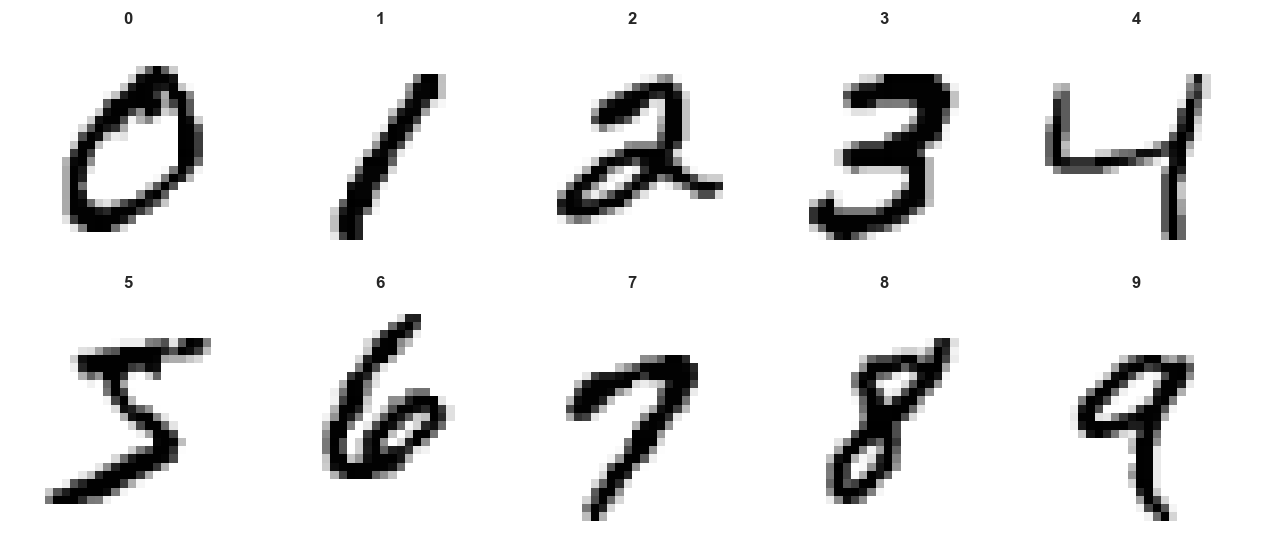

In [62]:
data = load_mnist_data(flatten=True)
x_train = data["x_train"]
y_train = data["y_train"]
x_test = data["x_test"]
y_test = data["y_test"]

sample_indices = [int(np.flatnonzero(y_train == digit)[0]) for digit in range(10)]
fig, axes = plt.subplots(2, 5, figsize=(10.5, 4.4), constrained_layout=True)
for ax, digit, idx in zip(axes.ravel(), range(10), sample_indices):
    ax.imshow(reshape_heatmap(x_train[idx], (28, 28)), cmap="gray_r")
    ax.set_title(str(digit), fontsize=10)
    ax.axis("off")
plt.show()


### Target MLP

The classifier is trained first and then frozen for all explanation experiments.


Epoch 1/4
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8936 - loss: 0.3578 - val_accuracy: 0.9678 - val_loss: 0.1153
Epoch 2/4
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9551 - loss: 0.1494 - val_accuracy: 0.9743 - val_loss: 0.0890
Epoch 3/4
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9666 - loss: 0.1092 - val_accuracy: 0.9755 - val_loss: 0.0801
Epoch 4/4
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9734 - loss: 0.0869 - val_accuracy: 0.9787 - val_loss: 0.0722


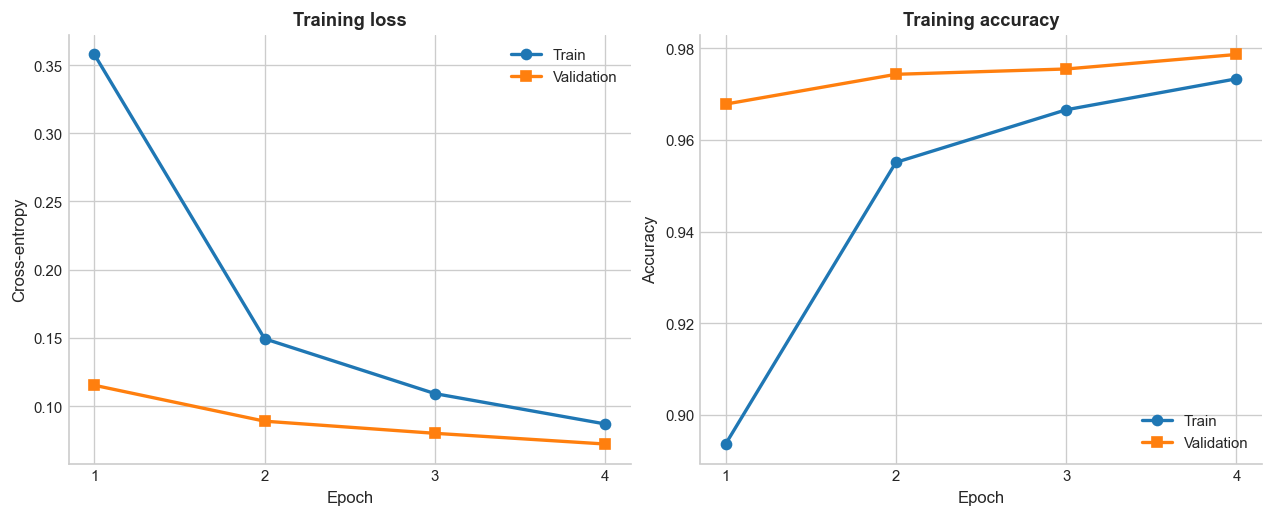

In [63]:
target_model, history = train_target_mlp(x_train, y_train, config=MLP_CONFIG, verbose=1)
test_metrics = target_model.evaluate(x_test, y_test)

epochs = np.arange(1, len(history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)

axes[0].plot(epochs, history["loss"], marker="o", linewidth=2)
axes[0].plot(epochs, history["val_loss"], marker="s", linewidth=2)
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].set_xticks(epochs)
axes[0].legend(["Train", "Validation"], frameon=False)

axes[1].plot(epochs, history["accuracy"], marker="o", linewidth=2)
axes[1].plot(epochs, history["val_accuracy"], marker="s", linewidth=2)
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks(epochs)
axes[1].legend(["Train", "Validation"], frameon=False)

plt.show()


### One-vs-Rest Target

The target quantity is the logit of the selected class probability.


In [64]:
x_fit, y_fit_true = stratified_subsample(x_train, y_train, FIT_SAMPLE_SIZE, random_state=SEED)
x_val, y_val_true = stratified_subsample(x_test, y_test, VALIDATION_SAMPLE_SIZE, random_state=SEED + 1)

positive_prob_fit, logits_fit = prepare_class_logits(target_model, x_fit, CLASS_INDEX)
positive_prob_val, logits_val = prepare_class_logits(target_model, x_val, CLASS_INDEX)

linear_baseline = LinearLogitSurrogate()
linear_baseline.fit(x_fit, logits_fit)
linear_val_pred = linear_baseline.predict_logit(x_val)
linear_val_mse = float(np.mean((linear_val_pred - logits_val) ** 2))


### DMM-MEN Fit

A global linear baseline and DMM-MEN are compared on held-out logits.


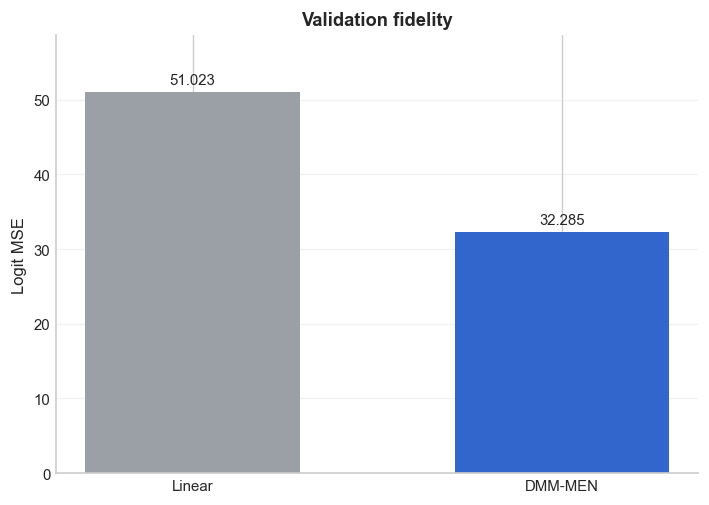

In [65]:
dmm_model = fit_dmm_men(x_fit, logits_fit, config=DMM_CONFIG)
dmm_val_pred = dmm_model.predict_logit(x_val)
dmm_val_mse = float(np.mean((dmm_val_pred - logits_val) ** 2))

fig, ax = plt.subplots(figsize=(5.8, 4.1), constrained_layout=True)
fidelity_names = ["Linear", "DMM-MEN"]
fidelity_values = [linear_val_mse, dmm_val_mse]
bars = ax.bar(fidelity_names, fidelity_values, color=["#9aa0a6", COLORS["DMM-MEN"]], width=0.58)
ax.set_title("Validation fidelity")
ax.set_ylabel("Logit MSE")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.margins(y=0.15)
ax.grid(True, axis="y", alpha=0.25)
plt.show()


### Global Component Maps

Each panel shows one DMM-MEN component on the 28 x 28 grid.


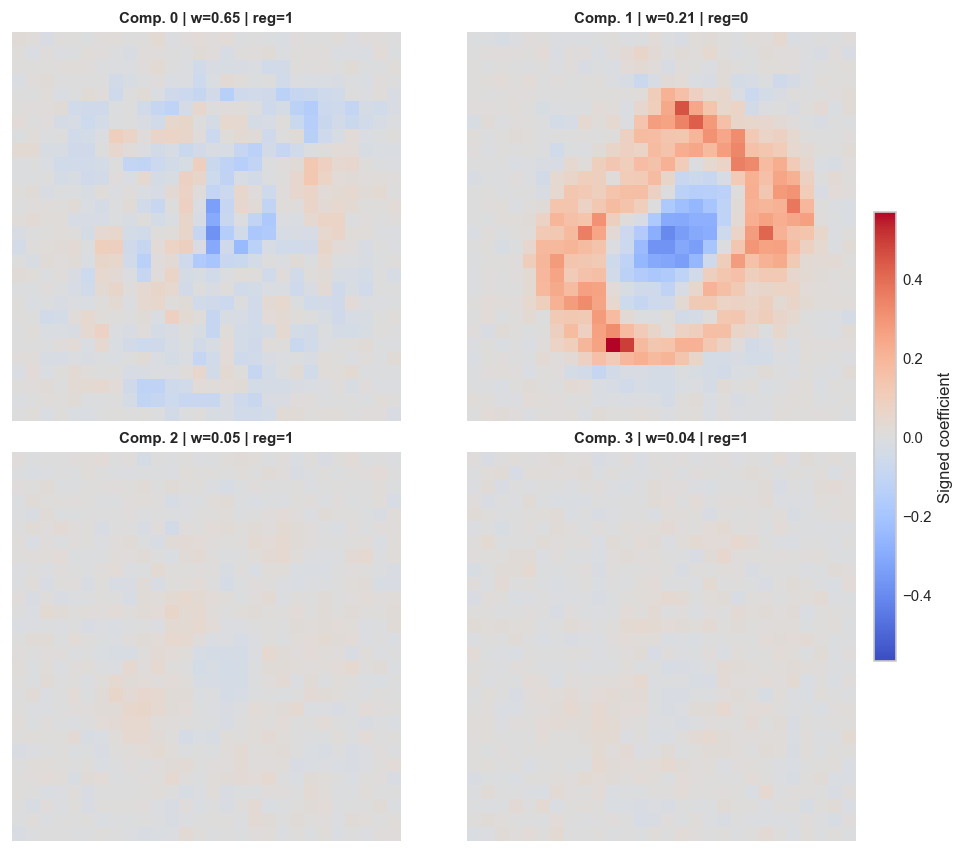

In [66]:
patterns = dmm_model.global_patterns(top_k=GLOBAL_TOP_K)
patterns = sorted(patterns, key=lambda pattern: pattern["mixture_weight"], reverse=True)[:4]

fig, axes = plt.subplots(2, 2, figsize=(8.4, 7.0), constrained_layout=True)
vmax = max(float(np.max(np.abs(pattern["heatmap"]))) for pattern in patterns)
for ax, pattern in zip(axes.ravel(), patterns):
    heat = ax.imshow(pattern["heatmap"], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(
        f"Comp. {pattern['component']} | w={pattern['mixture_weight']:.2f} | reg={pattern['regime']}",
        fontsize=9,
    )
    ax.axis("off")
for ax in axes.ravel()[len(patterns):]:
    ax.axis("off")
add_shared_colorbar(fig, heat, axes, "Signed coefficient")
plt.show()


### LIME Aggregation

LIME is aggregated over predicted positives to obtain a global comparison map.


In [67]:
fit_predicted_labels = np.argmax(target_model.predict_proba(x_fit), axis=1)
predicted_positive_indices = np.flatnonzero(fit_predicted_labels == CLASS_INDEX)
if predicted_positive_indices.size == 0:
    predicted_positive_indices = np.flatnonzero(y_fit_true == CLASS_INDEX)
predicted_positive_pool = x_fit[predicted_positive_indices]
positive_reference_image = predicted_positive_pool.mean(axis=0)

feature_names = [f"pixel_{idx}" for idx in range(x_fit.shape[1])]
class_names = [str(idx) for idx in range(10)]
lime_explainer = LimeTabularExplainer(
    training_data=x_fit,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=False,
    random_state=LIME_RANDOM_STATE,
)

def top_positive_indices(values, top_k):
    values = np.maximum(np.asarray(values, dtype=float), 0.0)
    top_k = max(1, min(top_k, values.size))
    if np.allclose(values, 0.0):
        return top_k_indices(values, top_k)
    indices = np.argpartition(values, -top_k)[-top_k:]
    return indices[np.argsort(values[indices])[::-1]]

def normalize_signed(values):
    values = np.asarray(values, dtype=float)
    scale = max(float(np.max(np.abs(values))), 1e-8)
    return values / scale

def normalize_positive(values):
    values = np.maximum(np.asarray(values, dtype=float), 0.0)
    scale = max(float(np.max(values)), 1e-8)
    return values / scale

def masked_image_from_indices(image, selected_pixels):
    selected_pixels = np.asarray(selected_pixels, dtype=int)
    masked = np.zeros_like(image)
    masked[selected_pixels] = image[selected_pixels]
    return masked

def dense_lime_weights(image, num_features=LIME_NUM_FEATURES, num_samples=LIME_NUM_SAMPLES):
    explanation = lime_explainer.explain_instance(
        data_row=np.asarray(image, dtype=float),
        predict_fn=target_model.predict_proba,
        labels=(CLASS_INDEX,),
        num_features=min(num_features, x_fit.shape[1]),
        num_samples=num_samples,
    )
    dense = np.zeros(x_fit.shape[1], dtype=float)
    local_map = explanation.local_exp.get(CLASS_INDEX, [])
    for feature_idx, weight in local_map:
        dense[int(feature_idx)] = float(weight)
    return dense

def dmm_local_positive_support(image, explanation=None):
    explanation = explanation or dmm_model.explain_instance(image, top_k=max(TOP_N_VALUES))
    contributions = np.asarray(explanation["contributions"], dtype=float)
    return np.maximum(contributions, 0.0)

def lime_local_positive_support(image, dense_weights=None):
    dense_weights = dense_lime_weights(image) if dense_weights is None else np.asarray(dense_weights, dtype=float)
    contributions = np.asarray(image, dtype=float) * dense_weights
    return np.maximum(contributions, 0.0), contributions, dense_weights

def positive_class_rate(images):
    probabilities = target_model.predict_proba(images)
    return classification_rate(probabilities, CLASS_INDEX)

def draw_bootstrap_groups(x_source, y_source, class_index, random_state, bootstrap_fraction=0.30):
    local_rng = np.random.default_rng(random_state)
    sample_size = max(50, int(bootstrap_fraction * len(x_source)))
    bootstrap_indices = local_rng.choice(len(x_source), size=sample_size, replace=True)
    x_boot = x_source[bootstrap_indices].copy()
    y_boot = y_source[bootstrap_indices]
    predicted_labels = np.argmax(target_model.predict_proba(x_boot), axis=1)
    positive_idx = np.flatnonzero(predicted_labels == class_index)
    negative_idx = np.flatnonzero(predicted_labels != class_index)
    if positive_idx.size == 0:
        positive_idx = np.flatnonzero(y_boot == class_index)
    if negative_idx.size == 0:
        negative_idx = np.flatnonzero(y_boot != class_index)
    if positive_idx.size == 0 or negative_idx.size == 0:
        raise RuntimeError("Bootstrap sample does not contain both positive and negative groups.")
    positive_mean = x_boot[positive_idx].mean(axis=0)
    return x_boot, positive_idx, negative_idx, positive_mean

def apply_scrutability_manipulation(x_boot, positive_idx, negative_idx, positive_mean, selected_pixels):
    selected_pixels = np.asarray(selected_pixels, dtype=int)
    manipulated = x_boot.copy()
    manipulated[np.ix_(positive_idx, selected_pixels)] = 0.0
    manipulated[np.ix_(negative_idx, selected_pixels)] = positive_mean[selected_pixels]
    return manipulated

def build_synthetic_batch(reference_image, selected_pixels, n_samples, random_state):
    local_rng = np.random.default_rng(random_state)
    synthetic = local_rng.uniform(0.0, 1.0, size=(n_samples, reference_image.size))
    selected_pixels = np.asarray(selected_pixels, dtype=int)
    synthetic[:, selected_pixels] = reference_image[selected_pixels]
    return synthetic

dmm_positive_evidence = np.sum(np.maximum(dmm_model.beta_mean_, 0.0) * dmm_model.pi_mean_[:, None], axis=0)
lime_subset_size = min(LIME_AGGREGATION_SIZE, predicted_positive_pool.shape[0])
lime_subset_indices = np.random.default_rng(SEED + 17).choice(predicted_positive_pool.shape[0], size=lime_subset_size, replace=False)
lime_subset = predicted_positive_pool[lime_subset_indices]
lime_dense_matrix = np.vstack([dense_lime_weights(image) for image in lime_subset])
lime_signed_average = lime_dense_matrix.mean(axis=0)
lime_positive_evidence = np.mean(np.maximum(lime_dense_matrix, 0.0), axis=0)

dmm_ranked_global_indices = top_positive_indices(dmm_positive_evidence, max(TOP_N_VALUES))
lime_ranked_global_indices = top_positive_indices(lime_positive_evidence, max(TOP_N_VALUES))


### Global Comparison

The maps below compare positive evidence selected by DMM-MEN and LIME.


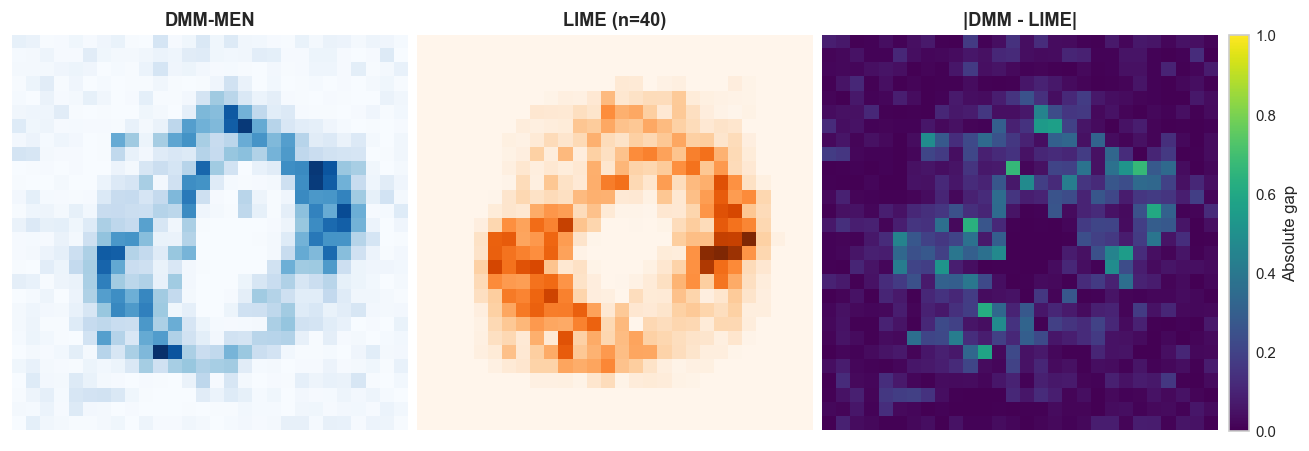

In [68]:
normalized_dmm_global = reshape_heatmap(normalize_positive(dmm_positive_evidence), (28, 28))
normalized_lime_global = reshape_heatmap(normalize_positive(lime_positive_evidence), (28, 28))
absolute_difference_map = np.abs(normalized_dmm_global - normalized_lime_global)

fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.8), constrained_layout=True)
im0 = axes[0].imshow(normalized_dmm_global, cmap="Blues", vmin=0.0, vmax=1.0)
axes[0].set_title("DMM-MEN")
axes[0].axis("off")
im1 = axes[1].imshow(normalized_lime_global, cmap="Oranges", vmin=0.0, vmax=1.0)
axes[1].set_title(f"LIME (n={lime_subset_size})")
axes[1].axis("off")
im2 = axes[2].imshow(absolute_difference_map, cmap="viridis", vmin=0.0, vmax=1.0)
axes[2].set_title("|DMM - LIME|")
axes[2].axis("off")
cbar = fig.colorbar(im2, ax=axes[2], fraction=0.05, pad=0.03)
cbar.set_label("Absolute gap")
plt.show()


### Scrutability: Examples

Selected pixels are removed from positive images and injected into negative images.


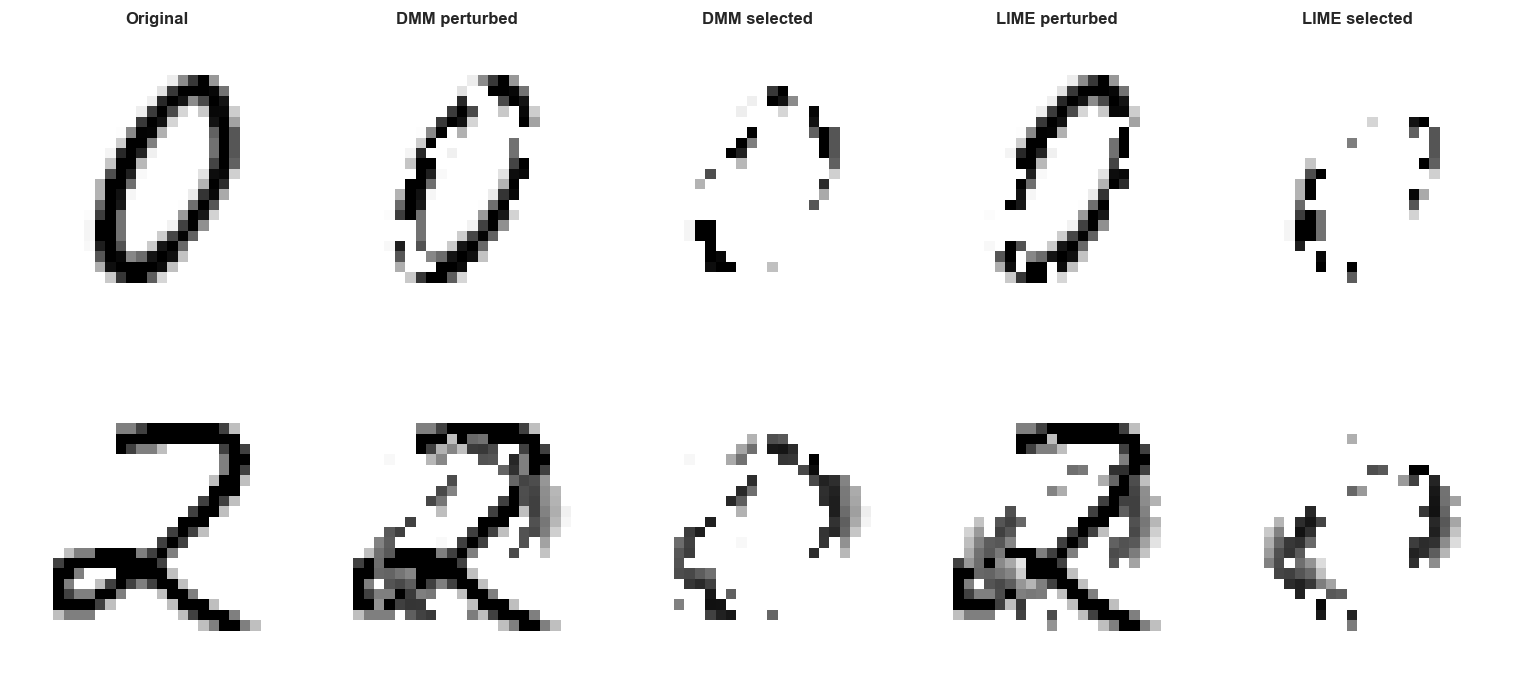

In [69]:
example_n = TOP_N_VALUES[min(1, len(TOP_N_VALUES) - 1)]
x_boot, positive_idx, negative_idx, positive_mean = draw_bootstrap_groups(
    x_fit, y_fit_true, CLASS_INDEX, random_state=SEED + 100
)
dmm_selected_pixels = dmm_ranked_global_indices[:example_n]
lime_selected_pixels = lime_ranked_global_indices[:example_n]
dmm_manipulated_boot = apply_scrutability_manipulation(x_boot, positive_idx, negative_idx, positive_mean, dmm_selected_pixels)
lime_manipulated_boot = apply_scrutability_manipulation(x_boot, positive_idx, negative_idx, positive_mean, lime_selected_pixels)

positive_example = int(positive_idx[0])
negative_example = int(negative_idx[0])
positive_dmm_mask = np.zeros_like(x_boot[positive_example])
positive_dmm_mask[dmm_selected_pixels] = x_boot[positive_example][dmm_selected_pixels]
positive_lime_mask = np.zeros_like(x_boot[positive_example])
positive_lime_mask[lime_selected_pixels] = x_boot[positive_example][lime_selected_pixels]
negative_dmm_mask = np.zeros_like(x_boot[negative_example])
negative_dmm_mask[dmm_selected_pixels] = positive_mean[dmm_selected_pixels]
negative_lime_mask = np.zeros_like(x_boot[negative_example])
negative_lime_mask[lime_selected_pixels] = positive_mean[lime_selected_pixels]

column_titles = ["Original", "DMM perturbed", "DMM selected", "LIME perturbed", "LIME selected"]
panel_grid = [
    [
        x_boot[positive_example],
        dmm_manipulated_boot[positive_example],
        positive_dmm_mask,
        lime_manipulated_boot[positive_example],
        positive_lime_mask,
    ],
    [
        x_boot[negative_example],
        dmm_manipulated_boot[negative_example],
        negative_dmm_mask,
        lime_manipulated_boot[negative_example],
        negative_lime_mask,
    ],
]

fig, axes = plt.subplots(2, 5, figsize=(12.5, 5.8), constrained_layout=True)
for row, vectors in enumerate(panel_grid):
    for col, vector in enumerate(vectors):
        axes[row, col].imshow(reshape_heatmap(vector, (28, 28)), cmap="gray_r")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(column_titles[col], fontsize=10)
    axes[row, 0].set_ylabel("Positive" if row == 0 else "Negative", fontsize=11)
plt.show()


### Scrutability: Curve

The positive prediction rate is measured after perturbing top-N pixels.


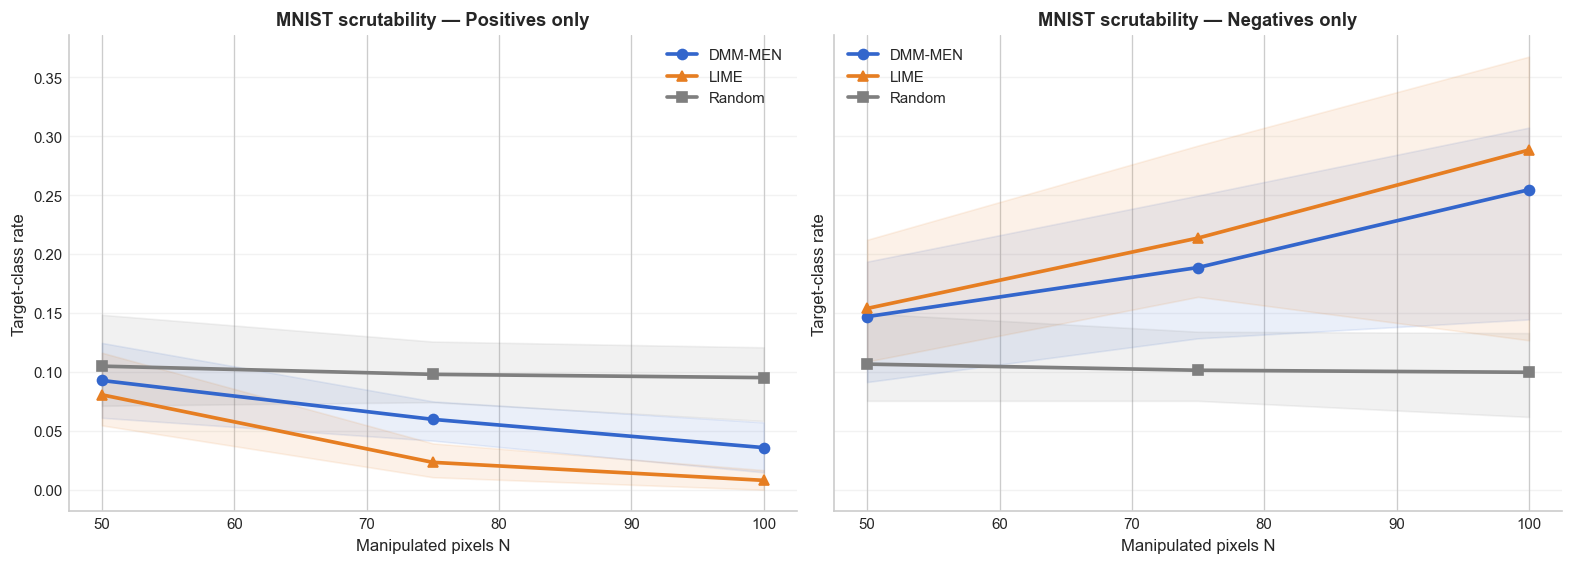

In [80]:
scrutability_results = []
for n_pixels in TOP_N_VALUES:
    dmm_rates_pos, dmm_rates_neg = [], []
    lime_rates_pos, lime_rates_neg = [], []
    random_rates_pos, random_rates_neg = [], []

    for repeat in range(BOOTSTRAP_REPEATS):
        repeat_seed = SEED + 1000 + 37 * repeat + n_pixels
        x_boot, positive_idx, negative_idx, positive_mean = draw_bootstrap_groups(
            x_fit, y_fit_true, CLASS_INDEX, random_state=repeat_seed
        )
        dmm_selected    = dmm_ranked_global_indices[:n_pixels]
        lime_selected   = lime_ranked_global_indices[:n_pixels]
        random_selected = np.random.default_rng(repeat_seed).choice(x_fit.shape[1], size=n_pixels, replace=False)

        for selected, rates_pos, rates_neg in [
            (dmm_selected,    dmm_rates_pos,    dmm_rates_neg),
            (lime_selected,   lime_rates_pos,   lime_rates_neg),
            (random_selected, random_rates_pos, random_rates_neg),
        ]:
            manip_pos = apply_scrutability_manipulation(x_boot, positive_idx, [],           positive_mean, selected)
            manip_neg = apply_scrutability_manipulation(x_boot, [],           negative_idx, positive_mean, selected)
            rates_pos.append(positive_class_rate(manip_pos))
            rates_neg.append(positive_class_rate(manip_neg))

    scrutability_results.append({
        "n_pixels":        n_pixels,
        "dmm_mean_pos":    float(np.mean(dmm_rates_pos)),    "dmm_ci_pos":    bootstrap_ci(dmm_rates_pos),
        "lime_mean_pos":   float(np.mean(lime_rates_pos)),   "lime_ci_pos":   bootstrap_ci(lime_rates_pos),
        "random_mean_pos": float(np.mean(random_rates_pos)), "random_ci_pos": bootstrap_ci(random_rates_pos),
        "dmm_mean_neg":    float(np.mean(dmm_rates_neg)),    "dmm_ci_neg":    bootstrap_ci(dmm_rates_neg),
        "lime_mean_neg":   float(np.mean(lime_rates_neg)),   "lime_ci_neg":   bootstrap_ci(lime_rates_neg),
        "random_mean_neg": float(np.mean(random_rates_neg)), "random_ci_neg": bootstrap_ci(random_rates_neg),
    })


scrutability_x = [r["n_pixels"] for r in scrutability_results]

fig, (ax_pos, ax_neg) = plt.subplots(1, 2, figsize=(13.0, 4.6), constrained_layout=True, sharey=True)

for ax, suffix, title in [
    (ax_pos, "pos", "MNIST scrutability — Positives only"),
    (ax_neg, "neg", "MNIST scrutability — Negatives only"),
]:
    for key, marker, label in [
        ("dmm",    "o", "DMM-MEN"),
        ("lime",   "^", "LIME"),
        ("random", "s", "Random"),
    ]:
        mean = [r[f"{key}_mean_{suffix}"] for r in scrutability_results]
        low  = [r[f"{key}_ci_{suffix}"][0] for r in scrutability_results]
        high = [r[f"{key}_ci_{suffix}"][1] for r in scrutability_results]
        ax.plot(scrutability_x, mean, marker=marker, linewidth=2.2, color=COLORS[label], label=label)
        ax.fill_between(scrutability_x, low, high, color=COLORS[label], alpha=0.10)

    ax.set_title(title)
    ax.set_xlabel("Manipulated pixels N")
    ax.set_ylabel("Target-class rate")
    ax.legend(frameon=False, loc="best")
    ax.grid(True, axis="y", alpha=0.25)

plt.show()

### Synthesis: Examples

Only the selected pixels are fixed; the remaining pixels are random.


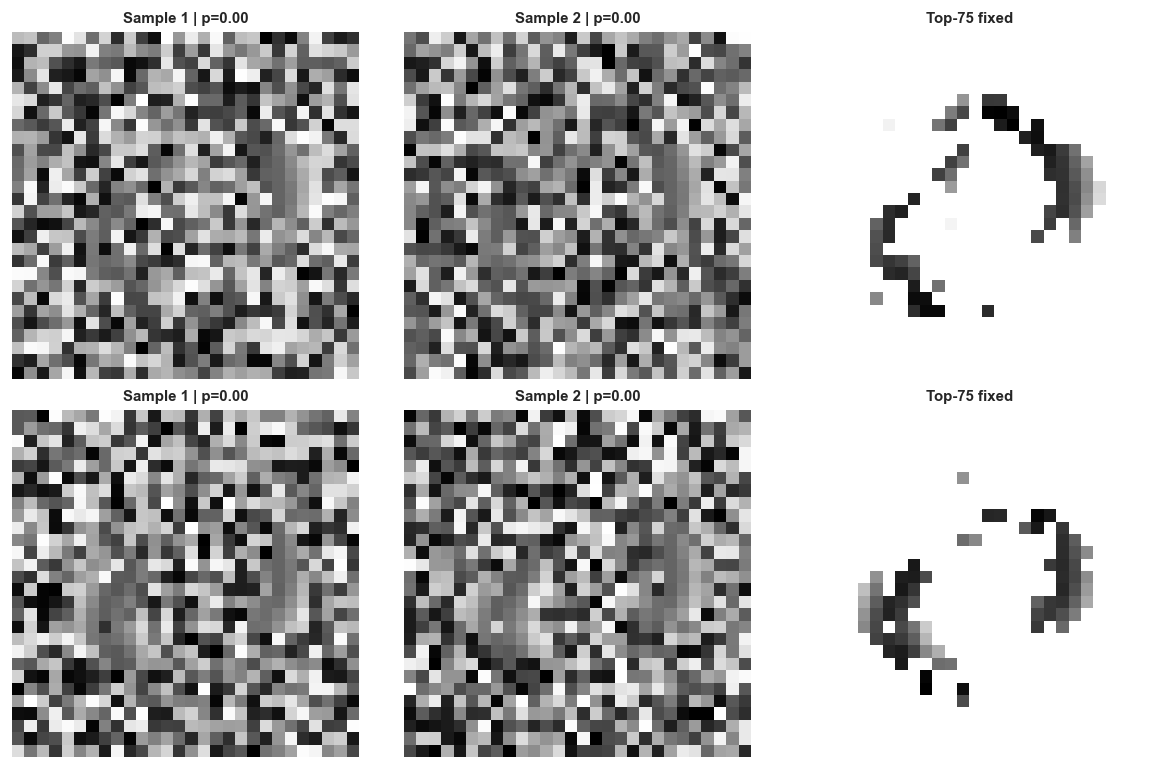

In [71]:
synthetic_n = TOP_N_VALUES[min(1, len(TOP_N_VALUES) - 1)]
dmm_synthetic_examples = build_synthetic_batch(
    positive_reference_image,
    dmm_ranked_global_indices[:synthetic_n],
    n_samples=2,
    random_state=SEED + 500,
)
lime_synthetic_examples = build_synthetic_batch(
    positive_reference_image,
    lime_ranked_global_indices[:synthetic_n],
    n_samples=2,
    random_state=SEED + 600,
)
dmm_synthetic_probs = target_model.predict_proba(dmm_synthetic_examples)[:, CLASS_INDEX]
lime_synthetic_probs = target_model.predict_proba(lime_synthetic_examples)[:, CLASS_INDEX]
dmm_fixed_mask = np.zeros_like(positive_reference_image)
dmm_fixed_mask[dmm_ranked_global_indices[:synthetic_n]] = positive_reference_image[dmm_ranked_global_indices[:synthetic_n]]
lime_fixed_mask = np.zeros_like(positive_reference_image)
lime_fixed_mask[lime_ranked_global_indices[:synthetic_n]] = positive_reference_image[lime_ranked_global_indices[:synthetic_n]]

fig, axes = plt.subplots(2, 3, figsize=(9.8, 6.3), constrained_layout=True)
row_payload = [
    ("DMM-MEN", dmm_synthetic_examples, dmm_synthetic_probs, dmm_fixed_mask),
    ("LIME", lime_synthetic_examples, lime_synthetic_probs, lime_fixed_mask),
]
for row, (method_name, images, probs, fixed_mask) in enumerate(row_payload):
    for col in range(2):
        axes[row, col].imshow(reshape_heatmap(images[col], (28, 28)), cmap="gray_r")
        axes[row, col].set_title(f"Sample {col + 1} | p={probs[col]:.2f}", fontsize=9)
        axes[row, col].axis("off")
    axes[row, 2].imshow(reshape_heatmap(fixed_mask, (28, 28)), cmap="gray_r")
    axes[row, 2].set_title(f"Top-{synthetic_n} fixed", fontsize=9)
    axes[row, 2].axis("off")
    axes[row, 0].set_ylabel(method_name, fontsize=11)
plt.show()


### Synthesis: Curve

Synthetic images are generated from the selected pixels.


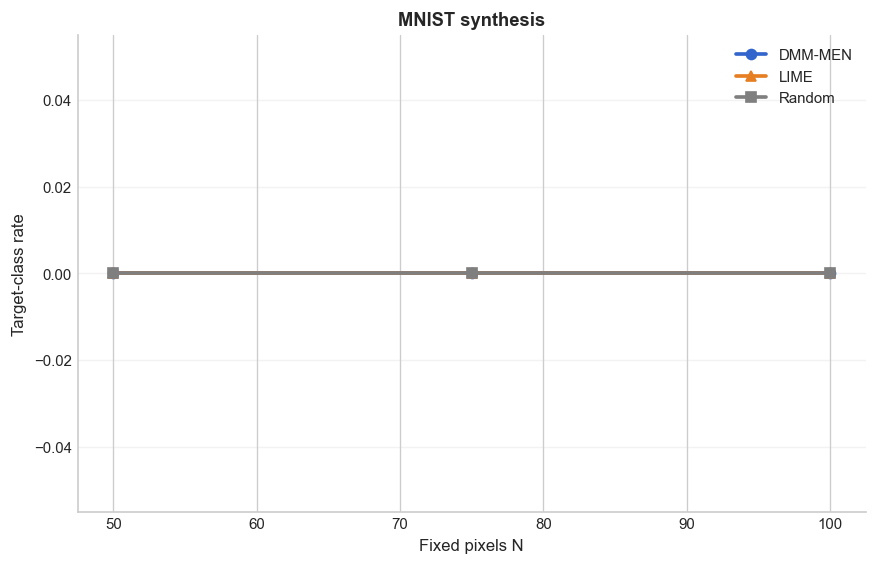

In [72]:
synthesis_results = []
for n_pixels in TOP_N_VALUES:
    dmm_rates = []
    lime_rates = []
    random_rates = []
    for repeat in range(BOOTSTRAP_REPEATS):
        repeat_seed = SEED + 2000 + 41 * repeat + n_pixels
        dmm_selected = dmm_ranked_global_indices[:n_pixels]
        lime_selected = lime_ranked_global_indices[:n_pixels]
        random_selected = np.random.default_rng(repeat_seed).choice(x_fit.shape[1], size=n_pixels, replace=False)
        dmm_synthetic = build_synthetic_batch(positive_reference_image, dmm_selected, n_samples=256, random_state=repeat_seed)
        lime_synthetic = build_synthetic_batch(positive_reference_image, lime_selected, n_samples=256, random_state=repeat_seed + 1)
        random_synthetic = build_synthetic_batch(positive_reference_image, random_selected, n_samples=256, random_state=repeat_seed + 2)
        dmm_rates.append(positive_class_rate(dmm_synthetic))
        lime_rates.append(positive_class_rate(lime_synthetic))
        random_rates.append(positive_class_rate(random_synthetic))
    synthesis_results.append(
        {
            "n_pixels": n_pixels,
            "dmm_mean": float(np.mean(dmm_rates)),
            "dmm_ci": bootstrap_ci(dmm_rates),
            "lime_mean": float(np.mean(lime_rates)),
            "lime_ci": bootstrap_ci(lime_rates),
            "random_mean": float(np.mean(random_rates)),
            "random_ci": bootstrap_ci(random_rates),
        }
    )


synthesis_x = [item["n_pixels"] for item in synthesis_results]
dmm_mean = [item["dmm_mean"] for item in synthesis_results]
dmm_low = [item["dmm_ci"][0] for item in synthesis_results]
dmm_high = [item["dmm_ci"][1] for item in synthesis_results]
lime_mean = [item["lime_mean"] for item in synthesis_results]
lime_low = [item["lime_ci"][0] for item in synthesis_results]
lime_high = [item["lime_ci"][1] for item in synthesis_results]
random_mean = [item["random_mean"] for item in synthesis_results]
random_low = [item["random_ci"][0] for item in synthesis_results]
random_high = [item["random_ci"][1] for item in synthesis_results]

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
ax.plot(synthesis_x, dmm_mean, marker="o", linewidth=2.2, color=COLORS["DMM-MEN"], label="DMM-MEN")
ax.fill_between(synthesis_x, dmm_low, dmm_high, color=COLORS["DMM-MEN"], alpha=0.10)
ax.plot(synthesis_x, lime_mean, marker="^", linewidth=2.2, color=COLORS["LIME"], label="LIME")
ax.fill_between(synthesis_x, lime_low, lime_high, color=COLORS["LIME"], alpha=0.10)
ax.plot(synthesis_x, random_mean, marker="s", linewidth=2.2, color=COLORS["Random"], label="Random")
ax.fill_between(synthesis_x, random_low, random_high, color=COLORS["Random"], alpha=0.12)
ax.set_title("MNIST synthesis")
ax.set_xlabel("Fixed pixels N")
ax.set_ylabel("Target-class rate")
ax.legend(frameon=False, loc="best")
ax.grid(True, axis="y", alpha=0.25)
plt.show()


### Local MNIST Explanations

DMM-MEN and LIME are compared on individual test images.


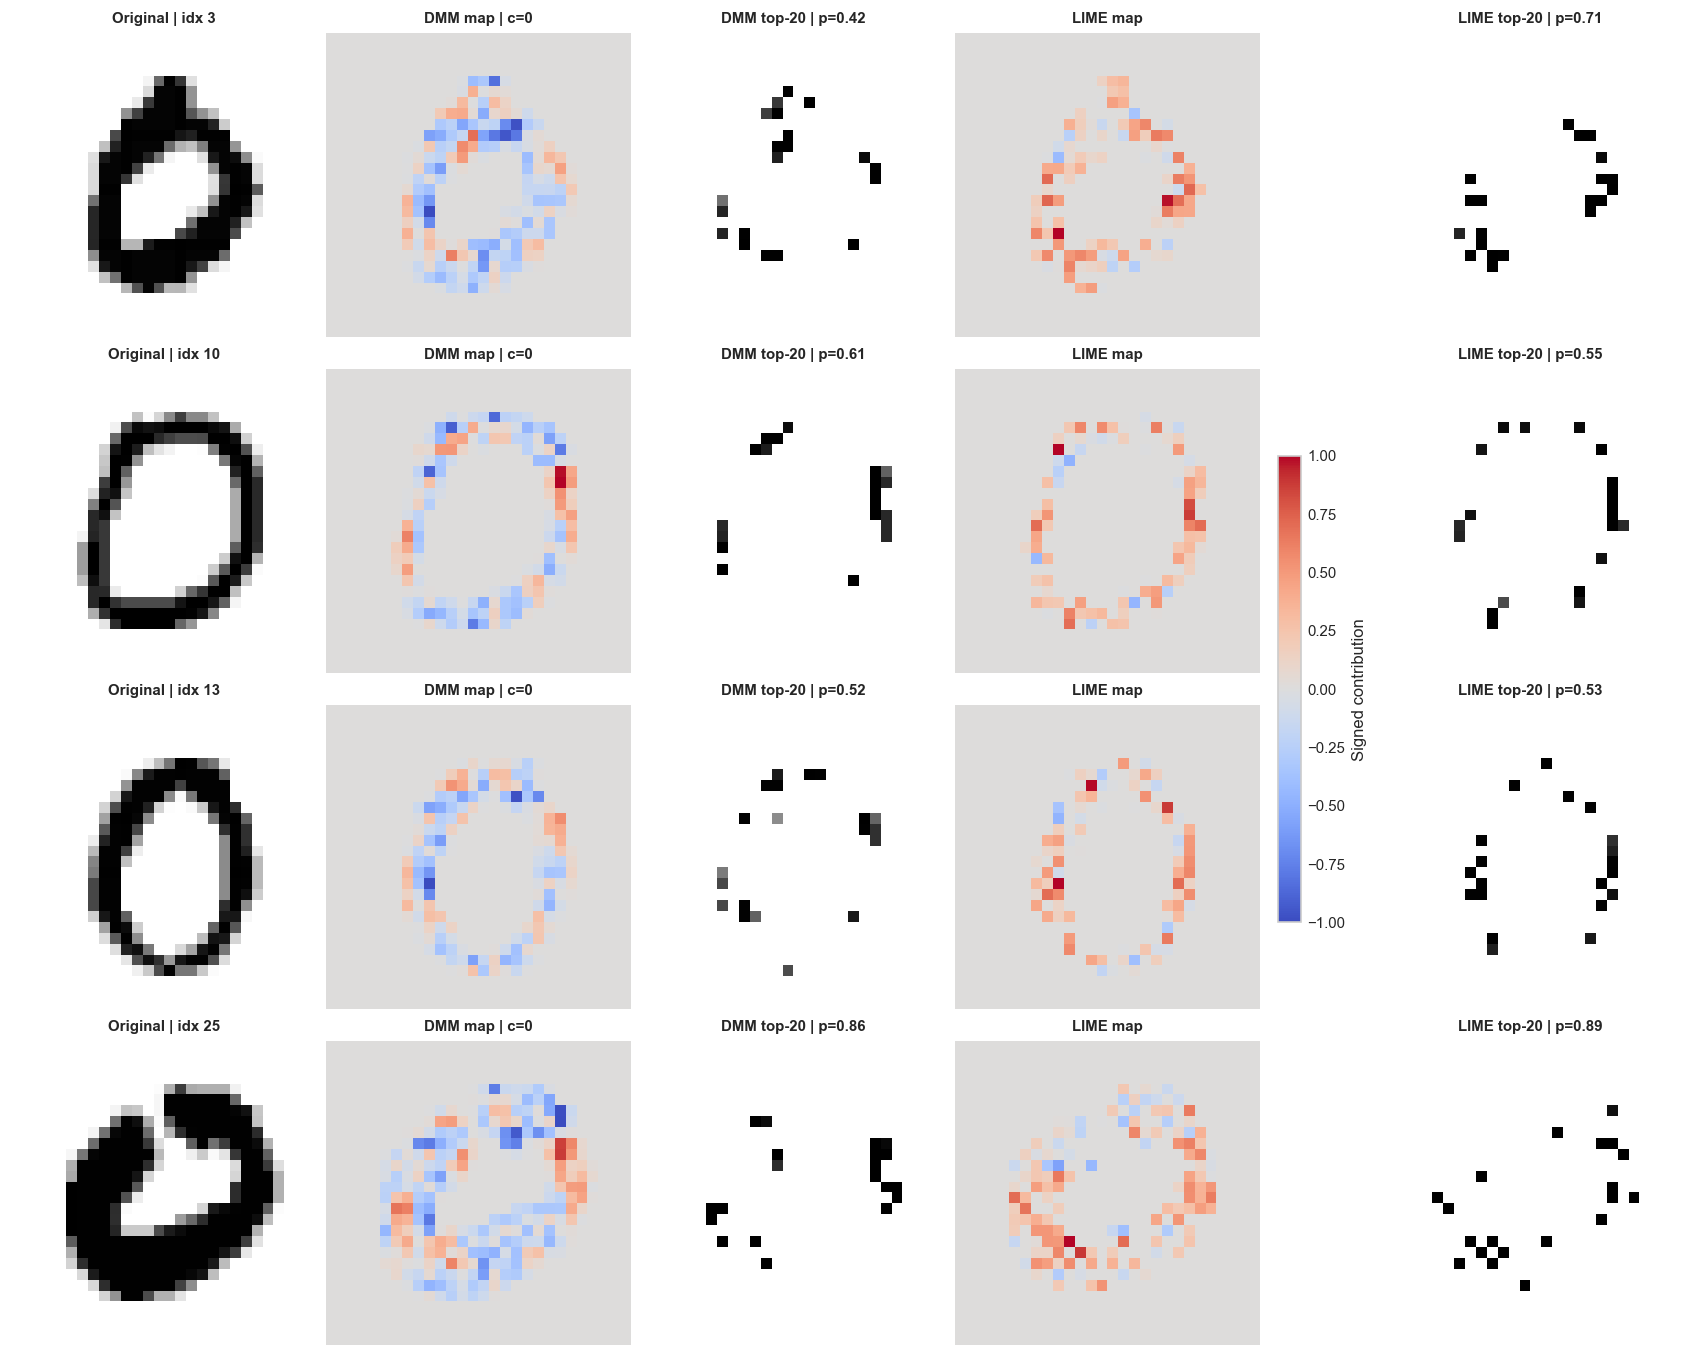

In [73]:
example_indices = np.flatnonzero(y_test == CLASS_INDEX)[:4]
local_payload = []
for idx in example_indices:
    image = x_test[idx]
    dmm_explanation = dmm_model.explain_instance(image, top_k=max(TOP_K_LOCAL, max(TOP_N_VALUES)))
    dmm_positive_support = dmm_local_positive_support(image, explanation=dmm_explanation)
    dmm_selected = top_positive_indices(dmm_positive_support, TOP_K_LOCAL)
    dmm_masked = masked_image_from_indices(image, dmm_selected)
    dmm_masked_prob = float(target_model.predict_proba(dmm_masked.reshape(1, -1))[0, CLASS_INDEX])

    lime_dense = dense_lime_weights(image)
    lime_positive_support, lime_contributions, _ = lime_local_positive_support(image, dense_weights=lime_dense)
    lime_selected = top_positive_indices(lime_positive_support, TOP_K_LOCAL)
    lime_masked = masked_image_from_indices(image, lime_selected)
    lime_masked_prob = float(target_model.predict_proba(lime_masked.reshape(1, -1))[0, CLASS_INDEX])

    local_payload.append({
        "index": int(idx),
        "image": image,
        "dmm_contrib": np.asarray(dmm_explanation["contributions"], dtype=float),
        "dmm_masked": dmm_masked,
        "dmm_masked_prob": dmm_masked_prob,
        "dmm_component": int(dmm_explanation["dominant_component"]),
        "lime_contrib": np.asarray(lime_contributions, dtype=float),
        "lime_masked": lime_masked,
        "lime_masked_prob": lime_masked_prob,
    })

fig, axes = plt.subplots(len(local_payload), 5, figsize=(14.0, 2.8 * len(local_payload)), constrained_layout=True)
if len(local_payload) == 1:
    axes = np.array([axes])

for row, payload in enumerate(local_payload):
    axes[row, 0].imshow(reshape_heatmap(payload["image"], (28, 28)), cmap="gray_r")
    axes[row, 0].set_title(f"Original | idx {payload['index']}", fontsize=9)
    axes[row, 0].axis("off")

    dmm_map = reshape_heatmap(normalize_signed(payload["dmm_contrib"]), (28, 28))
    axes[row, 1].imshow(dmm_map, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    axes[row, 1].set_title(f"DMM map | c={payload['dmm_component']}", fontsize=9)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(reshape_heatmap(payload["dmm_masked"], (28, 28)), cmap="gray_r")
    axes[row, 2].set_title(f"DMM top-{TOP_K_LOCAL} | p={payload['dmm_masked_prob']:.2f}", fontsize=9)
    axes[row, 2].axis("off")

    lime_map = reshape_heatmap(normalize_signed(payload["lime_contrib"]), (28, 28))
    lime_im = axes[row, 3].imshow(lime_map, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    axes[row, 3].set_title("LIME map", fontsize=9)
    axes[row, 3].axis("off")

    axes[row, 4].imshow(reshape_heatmap(payload["lime_masked"], (28, 28)), cmap="gray_r")
    axes[row, 4].set_title(f"LIME top-{TOP_K_LOCAL} | p={payload['lime_masked_prob']:.2f}", fontsize=9)
    axes[row, 4].axis("off")

add_shared_colorbar(fig, lime_im, axes[:, 1:4], "Signed contribution")
plt.show()


### Local MNIST Comparison

The retained target probability is measured after keeping only the top-k pixels.


C:\Users\mathi\AppData\Local\Temp\ipykernel_36852\702996239.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\mathi\AppData\Local\Temp\ipykernel_36852\702996239.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right")


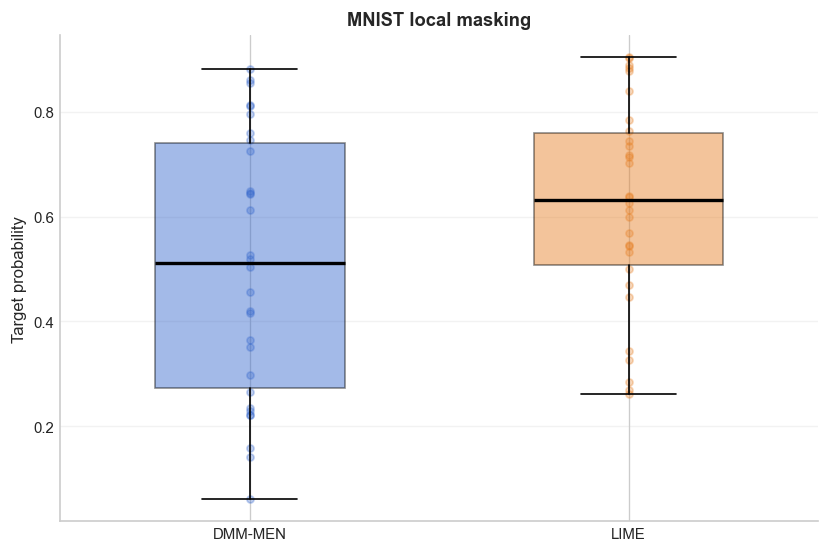

In [74]:
local_compare_indices = np.flatnonzero(y_test == CLASS_INDEX)[:LOCAL_COMPARE_SIZE]
original_probs = []
dmm_retained_probs = []
lime_retained_probs = []

for idx in local_compare_indices:
    image = x_test[idx]
    original_probs.append(float(target_model.predict_proba(image.reshape(1, -1))[0, CLASS_INDEX]))

    dmm_explanation = dmm_model.explain_instance(image, top_k=max(TOP_K_LOCAL, max(TOP_N_VALUES)))
    dmm_support = dmm_local_positive_support(image, explanation=dmm_explanation)
    dmm_selected = top_positive_indices(dmm_support, TOP_K_LOCAL)
    dmm_masked = masked_image_from_indices(image, dmm_selected)
    dmm_retained_probs.append(float(target_model.predict_proba(dmm_masked.reshape(1, -1))[0, CLASS_INDEX]))

    lime_dense = dense_lime_weights(image)
    lime_support, _, _ = lime_local_positive_support(image, dense_weights=lime_dense)
    lime_selected = top_positive_indices(lime_support, TOP_K_LOCAL)
    lime_masked = masked_image_from_indices(image, lime_selected)
    lime_retained_probs.append(float(target_model.predict_proba(lime_masked.reshape(1, -1))[0, CLASS_INDEX]))


fig, ax = plt.subplots(figsize=(6.8, 4.5), constrained_layout=True)
positions = [0, 1]
box = ax.boxplot(
    [dmm_retained_probs, lime_retained_probs],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    labels=["DMM-MEN", "LIME"],
    showfliers=False,
)
for patch, color in zip(box["boxes"], [COLORS["DMM-MEN"], COLORS["LIME"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)
ax.scatter(np.full(len(dmm_retained_probs), positions[0]), dmm_retained_probs, color=COLORS["DMM-MEN"], alpha=0.30, s=18)
ax.scatter(np.full(len(lime_retained_probs), positions[1]), lime_retained_probs, color=COLORS["LIME"], alpha=0.30, s=18)
ax.set_title("MNIST local masking")
ax.set_ylabel("Target probability")
ax.legend(frameon=False, loc="upper right")
ax.grid(True, axis="y", alpha=0.25)
plt.show()


## Part II - ImageNet / VGG16

The ImageNet section is local only and works in superpixel space.


### Superpixels

VGG16 is explained on fixed SLIC segmentations.


In [75]:
if RUN_IMAGENET:
    vgg16_model = VGG16(weights="imagenet")

    def resolve_imagenet_source(source):
        source = str(source)
        if source.startswith("http://") or source.startswith("https://"):
            return Path(get_file(Path(source).name, origin=source, cache_subdir="imagenet_examples"))
        return Path(source)

    def load_imagenet_rgb(source):
        path = resolve_imagenet_source(source)
        image = load_img(path, target_size=IMAGENET_IMAGE_SIZE)
        return img_to_array(image).astype("float32"), path

    def vgg16_predict(images):
        batch = np.asarray(images, dtype="float32")
        batch = preprocess_input(batch.copy())
        return vgg16_model.predict(batch, verbose=0)

    def make_segments(image):
        return slic(image / 255.0, n_segments=IMAGENET_SEGMENTS, compactness=10, sigma=1, start_label=0)

    def fudged_image(image):
        mean_color = image.mean(axis=(0, 1), keepdims=True)
        return np.broadcast_to(mean_color, image.shape).copy()

    def apply_segment_mask(image, segments, active_mask, baseline=None):
        baseline = fudged_image(image) if baseline is None else baseline.copy()
        output = baseline.copy()
        for segment_id, is_active in enumerate(np.asarray(active_mask, dtype=int)):
            if is_active:
                output[segments == segment_id] = image[segments == segment_id]
        return output

    def sample_binary_masks(n_samples, n_segments, random_state):
        local_rng = np.random.default_rng(random_state)
        masks = local_rng.integers(0, 2, size=(n_samples, n_segments))
        masks[0, :] = 1
        zero_rows = np.where(masks.sum(axis=1) == 0)[0]
        if zero_rows.size > 0:
            replacement_indices = local_rng.integers(0, n_segments, size=zero_rows.size)
            masks[zero_rows, replacement_indices] = 1
        return masks.astype(float)

    def segment_values_to_image(segments, values):
        values = np.asarray(values, dtype=float)
        canvas = np.zeros_like(segments, dtype=float)
        for segment_id in range(values.shape[0]):
            canvas[segments == segment_id] = values[segment_id]
        return canvas

    def explain_imagenet_with_dmm(image, segments, class_index, random_state):
        n_segments = int(segments.max()) + 1
        masks = sample_binary_masks(IMAGENET_NUM_PERTURBATIONS, n_segments, random_state)
        baseline = fudged_image(image)
        perturbed_images = np.stack([
            apply_segment_mask(image, segments, mask, baseline=baseline)
            for mask in masks
        ], axis=0)
        probabilities = vgg16_predict(perturbed_images)[:, class_index]
        logits = logit(probabilities)
        local_config = DMMMENConfig(
            n_components=min(6, max(3, n_segments)),
            n_regimes=3,
            burn_in=20,
            n_samples=30,
            thin=2,
            random_state=random_state,
            feature_shape=(1, n_segments),
        )
        local_model = fit_dmm_men(masks, logits, config=local_config)
        explanation = local_model.explain_instance(np.ones(n_segments, dtype=float), top_k=IMAGENET_TOP_K_SEGMENTS)
        coefficients = np.asarray(explanation["coefficients"], dtype=float)
        positive_support = np.maximum(coefficients, 0.0)
        top_segments = top_positive_indices(positive_support, min(IMAGENET_TOP_K_SEGMENTS_GRAPH, n_segments))
        return {
            "model": local_model,
            "coefficients": coefficients,
            "positive_support": positive_support,
            "top_segments": top_segments,
            "masks": masks,
            "probabilities": probabilities,
        }

    def explain_imagenet_with_lime(image, segments, class_index, random_state):
        explainer = lime_image.LimeImageExplainer(random_state=random_state)
        explanation = explainer.explain_instance(
            image=np.asarray(image, dtype=float),
            classifier_fn=vgg16_predict,
            labels=(class_index,),
            num_samples=LIME_NUM_SAMPLES,
            segmentation_fn=lambda _: segments,
        )
        n_segments = int(segments.max()) + 1
        weights = np.zeros(n_segments, dtype=float)
        for segment_id, weight in explanation.local_exp.get(class_index, []):
            weights[int(segment_id)] = float(weight)
        positive_support = np.maximum(weights, 0.0)
        top_segments = top_positive_indices(positive_support, min(IMAGENET_TOP_K_SEGMENTS_GRAPH, n_segments))
        return {
            "weights": weights,
            "positive_support": positive_support,
            "top_segments": top_segments,
        }


### Images and Segmentations

Each image is explained with respect to its top VGG16 prediction.


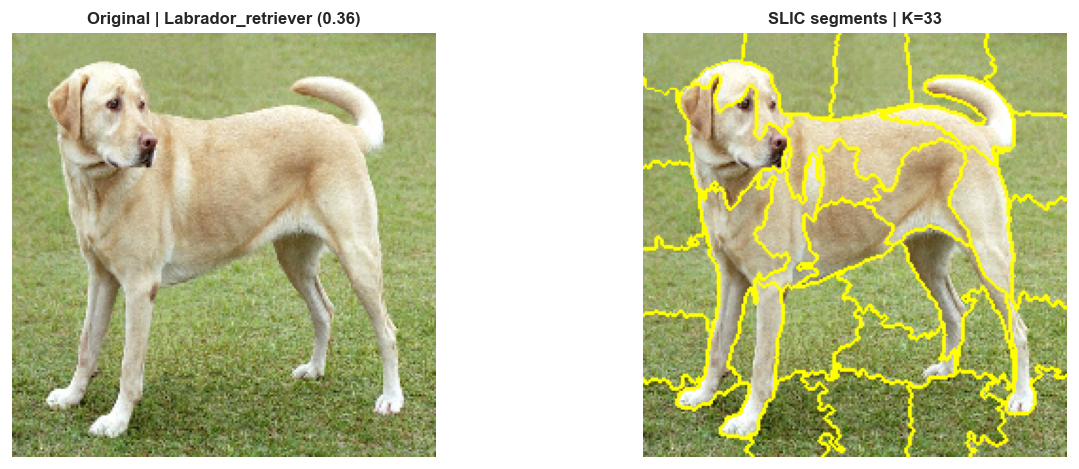

In [76]:
if RUN_IMAGENET:
    selected_sources = IMAGENET_SOURCES[: max(1, IMAGENET_LOCAL_COMPARE_SIZE)]
    imagenet_entries = []
    for source in selected_sources:
        image, resolved_path = load_imagenet_rgb(source)
        predictions = vgg16_predict(np.expand_dims(image, axis=0))
        decoded = decode_predictions(predictions, top=3)[0]
        target_class_index = int(np.argmax(predictions[0]))
        target_label = decoded[0][1]
        target_probability = float(predictions[0, target_class_index])
        segments = make_segments(image)
        imagenet_entries.append(
            {
                "source": source,
                "resolved_path": str(resolved_path),
                "image": image,
                "predictions": predictions[0],
                "decoded": decoded,
                "target_class_index": target_class_index,
                "target_label": target_label,
                "target_probability": target_probability,
                "segments": segments,
            }
        )

    fig, axes = plt.subplots(len(imagenet_entries), 2, figsize=(10.5, 3.8 * len(imagenet_entries)), constrained_layout=True)
    if len(imagenet_entries) == 1:
        axes = np.array([axes])
    for row, entry in enumerate(imagenet_entries):
        axes[row, 0].imshow(entry["image"].astype("uint8"))
        axes[row, 0].set_title(f"Original | {entry['target_label']} ({entry['target_probability']:.2f})", fontsize=10)
        axes[row, 0].axis("off")
        axes[row, 1].imshow(mark_boundaries(entry["image"] / 255.0, entry["segments"]))
        axes[row, 1].set_title(f"SLIC segments | K={int(entry['segments'].max()) + 1}", fontsize=10)
        axes[row, 1].axis("off")
    plt.show()
else:
    imagenet_entries = []


### Local ImageNet Comparison

Both explainers are evaluated on the same segmentation and the same target class.


100%|██████████| 1000/1000 [02:43<00:00,  6.11it/s]


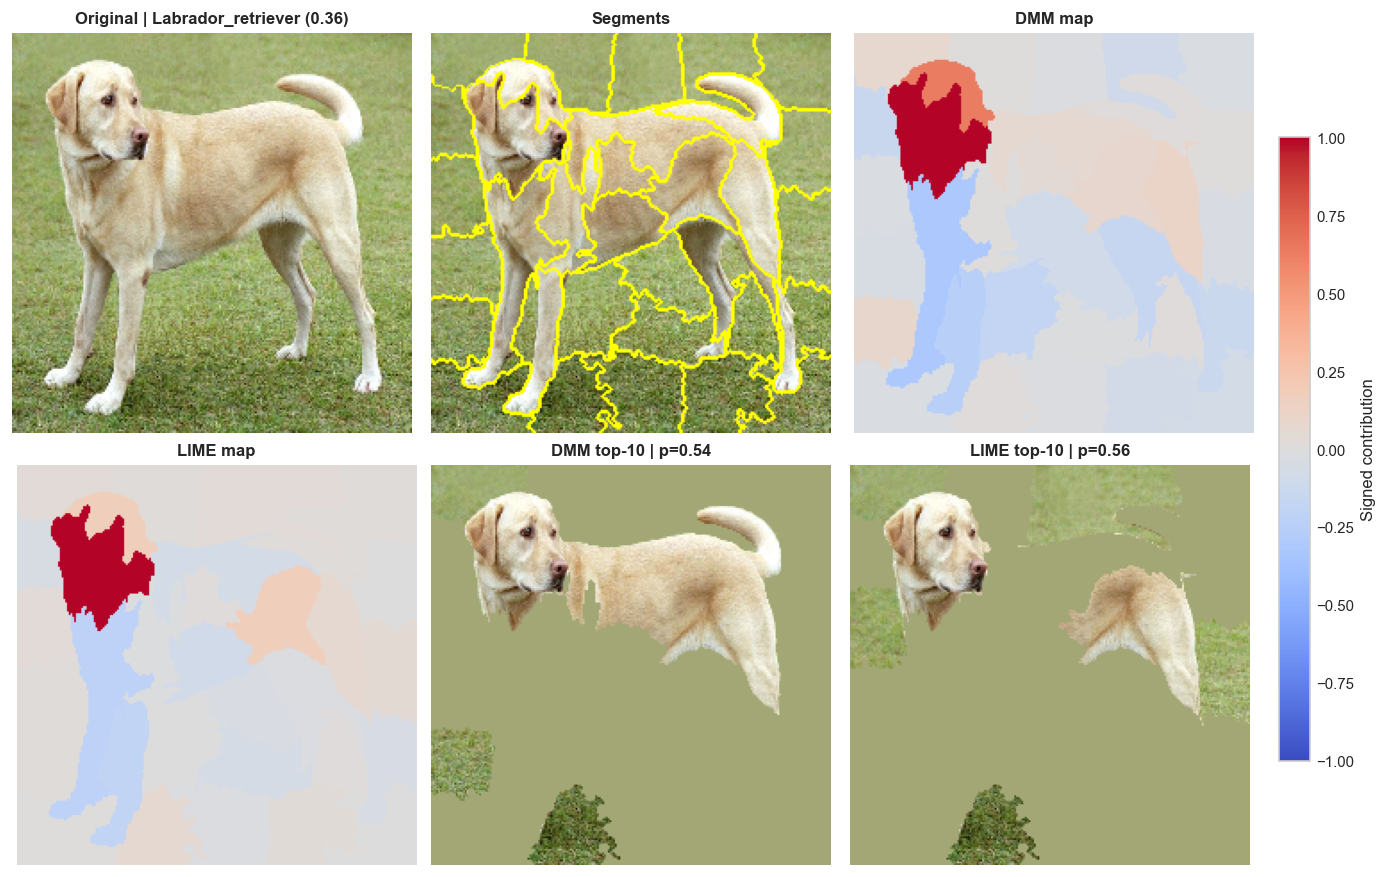

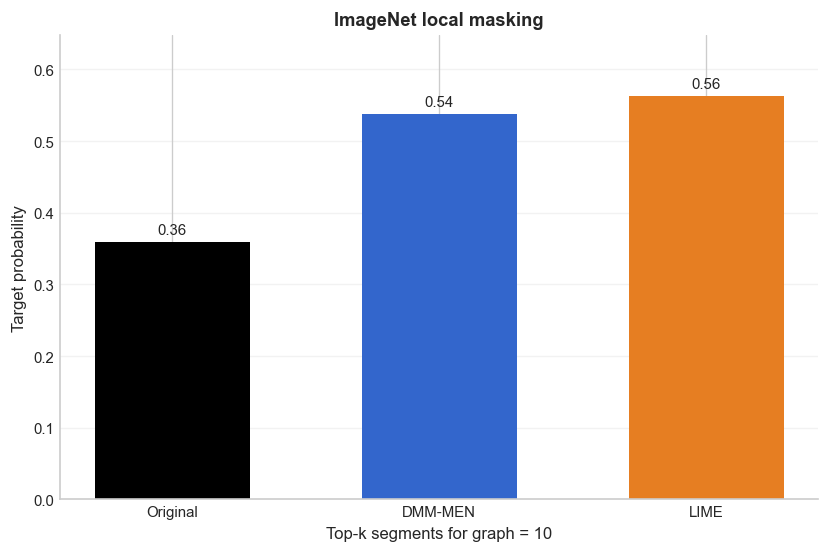

In [77]:
if RUN_IMAGENET and len(imagenet_entries) > 0:
    imagenet_results = []
    original_probs = []
    dmm_retained_probs = []
    lime_retained_probs = []
    dmm_retained_probs_graph = []
    lime_retained_probs_graph = []

    for image_id, entry in enumerate(imagenet_entries):
        image = entry["image"]
        segments = entry["segments"]
        class_index = entry["target_class_index"]
        baseline = fudged_image(image)
        dmm_result = explain_imagenet_with_dmm(image, segments, class_index, random_state=SEED + 300 + image_id)
        lime_result = explain_imagenet_with_lime(image, segments, class_index, random_state=SEED + 400 + image_id)

        dmm_signed_map = segment_values_to_image(segments, normalize_signed(dmm_result["coefficients"]))
        lime_signed_map = segment_values_to_image(segments, normalize_signed(lime_result["weights"]))
        n_segments = int(segments.max()) + 1
        dmm_mask = np.isin(np.arange(n_segments), dmm_result["top_segments"]).astype(float)
        lime_mask = np.isin(np.arange(n_segments), lime_result["top_segments"]).astype(float)
        dmm_masked = apply_segment_mask(image, segments, dmm_mask, baseline=baseline)
        lime_masked = apply_segment_mask(image, segments, lime_mask, baseline=baseline)

        dmm_top_segments_graph = top_positive_indices(
            dmm_result["positive_support"], min(IMAGENET_TOP_K_SEGMENTS_GRAPH, n_segments)
        )
        lime_top_segments_graph = top_positive_indices(
            lime_result["positive_support"], min(IMAGENET_TOP_K_SEGMENTS_GRAPH, n_segments)
        )
        dmm_mask_graph = np.isin(np.arange(n_segments), dmm_top_segments_graph).astype(float)
        lime_mask_graph = np.isin(np.arange(n_segments), lime_top_segments_graph).astype(float)
        dmm_masked_graph = apply_segment_mask(image, segments, dmm_mask_graph, baseline=baseline)
        lime_masked_graph = apply_segment_mask(image, segments, lime_mask_graph, baseline=baseline)

        original_prob = float(entry["predictions"][class_index])
        dmm_prob = float(vgg16_predict(np.expand_dims(dmm_masked, axis=0))[0, class_index])
        lime_prob = float(vgg16_predict(np.expand_dims(lime_masked, axis=0))[0, class_index])
        dmm_prob_graph = float(vgg16_predict(np.expand_dims(dmm_masked_graph, axis=0))[0, class_index])
        lime_prob_graph = float(vgg16_predict(np.expand_dims(lime_masked_graph, axis=0))[0, class_index])
        original_probs.append(original_prob)
        dmm_retained_probs.append(dmm_prob)
        lime_retained_probs.append(lime_prob)
        dmm_retained_probs_graph.append(dmm_prob_graph)
        lime_retained_probs_graph.append(lime_prob_graph)

        imagenet_results.append(
            {
                "target_label": entry["target_label"],
                "target_class_index": class_index,
                "original_prob": original_prob,
                "dmm_prob": dmm_prob,
                "lime_prob": lime_prob,
                "dmm_prob_graph": dmm_prob_graph,
                "lime_prob_graph": lime_prob_graph,
            }
        )

        fig = plt.figure(figsize=(11.5, 7.2), constrained_layout=True)
        grid = fig.add_gridspec(2, 3)
        ax00 = fig.add_subplot(grid[0, 0])
        ax01 = fig.add_subplot(grid[0, 1])
        ax02 = fig.add_subplot(grid[0, 2])
        ax10 = fig.add_subplot(grid[1, 0])
        ax11 = fig.add_subplot(grid[1, 1])
        ax12 = fig.add_subplot(grid[1, 2])

        ax00.imshow(image.astype("uint8"))
        ax00.set_title(f"Original | {entry['target_label']} ({original_prob:.2f})", fontsize=10)
        ax00.axis("off")

        ax01.imshow(mark_boundaries(image / 255.0, segments))
        ax01.set_title("Segments", fontsize=10)
        ax01.axis("off")

        ax02.imshow(dmm_signed_map, cmap="coolwarm", vmin=-1.0, vmax=1.0)
        ax02.set_title("DMM map", fontsize=10)
        ax02.axis("off")

        lime_im = ax10.imshow(lime_signed_map, cmap="coolwarm", vmin=-1.0, vmax=1.0)
        ax10.set_title("LIME map", fontsize=10)
        ax10.axis("off")

        ax11.imshow(dmm_masked.astype("uint8"))
        ax11.set_title(f"DMM top-{IMAGENET_TOP_K_SEGMENTS_GRAPH} | p={dmm_prob:.2f}", fontsize=10)
        ax11.axis("off")

        ax12.imshow(lime_masked.astype("uint8"))
        ax12.set_title(f"LIME top-{IMAGENET_TOP_K_SEGMENTS_GRAPH} | p={lime_prob:.2f}", fontsize=10)
        ax12.axis("off")

        add_shared_colorbar(fig, lime_im, [ax02, ax10], "Signed contribution")
        plt.show()

    fig, ax = plt.subplots(figsize=(6.8, 4.5), constrained_layout=True)
    if len(imagenet_results) == 1:
        labels = ["Original", "DMM-MEN", "LIME"]
        values = [original_probs[0], dmm_retained_probs_graph[0], lime_retained_probs_graph[0]]
        bars = ax.bar(labels, values, color=["black", COLORS["DMM-MEN"], COLORS["LIME"]], width=0.58)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
        ax.margins(y=0.15)
        ax.set_ylabel("Target probability")
    else:
        box = ax.boxplot(
            [dmm_retained_probs_graph, lime_retained_probs_graph],
            labels=["DMM-MEN", "LIME"],
            patch_artist=True,
            widths=0.5,
            showfliers=False,
        )
        for patch, color in zip(box["boxes"], [COLORS["DMM-MEN"], COLORS["LIME"]]):
            patch.set_facecolor(color)
            patch.set_alpha(0.45)
        ax.axhline(np.mean(original_probs), linestyle="--", color="black", linewidth=1.6, label="Original mean")
        ax.scatter(np.full(len(dmm_retained_probs_graph), 1), dmm_retained_probs_graph, color=COLORS["DMM-MEN"], alpha=0.30, s=18)
        ax.scatter(np.full(len(lime_retained_probs_graph), 2), lime_retained_probs_graph, color=COLORS["LIME"], alpha=0.30, s=18)
        ax.legend(frameon=False, loc="upper right")
        ax.set_ylabel("Target probability")
    ax.set_title("ImageNet local masking")
    ax.set_xlabel(f"Top-k segments for graph = {IMAGENET_TOP_K_SEGMENTS_GRAPH}")
    ax.grid(True, axis="y", alpha=0.25)
    plt.show()
